In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, median_absolute_error

In [4]:
data = pd.read_csv("dataset.csv")

In [5]:
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [6]:
data.shape

(195, 24)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [8]:
data.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [9]:
data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [10]:
data["status"].value_counts()

status
1    147
0     48
Name: count, dtype: int64

<Axes: xlabel='status', ylabel='count'>

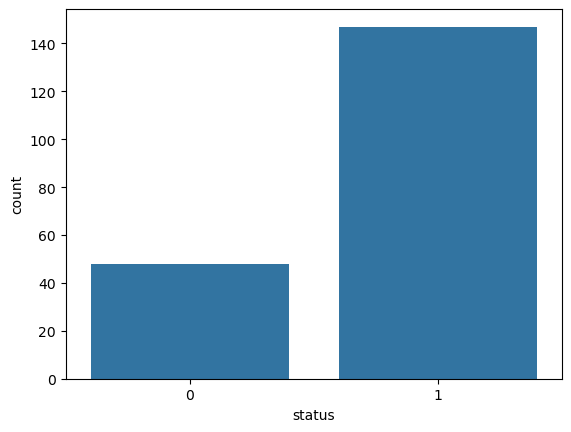

In [11]:
sns.countplot(x = "status", data = data)

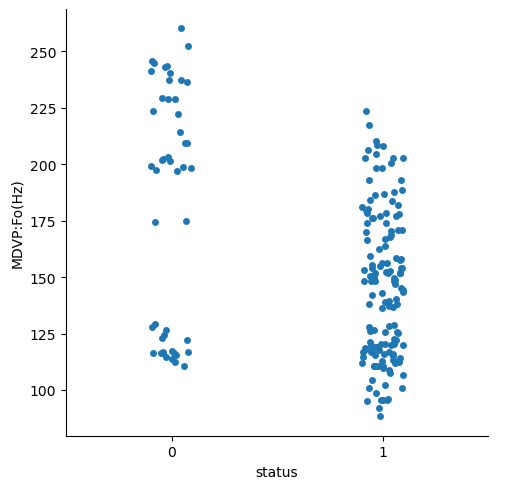

In [12]:
sns.catplot(x = "status", y = "MDVP:Fo(Hz)", data = data)

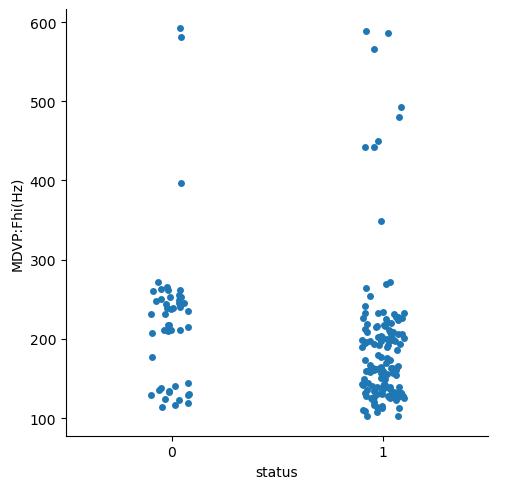

In [13]:
sns.catplot(x = "status", y = "MDVP:Fhi(Hz)", data = data)

In [16]:
data.groupby("status").mean(numeric_only=True)


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
status,,,,,,,,,,,,,,,,,,,,,
0,181.937771,223.636750,145.207292,0.003866,0.000023,0.001925,0.002056,0.005776,0.017615,0.162958,...,0.013305,0.028511,0.011483,24.678750,0.442552,0.695716,-6.759264,0.160292,2.154491,0.123017
1,145.180762,188.441463,106.893558,0.006989,0.000051,0.003757,0.003900,0.011273,0.033658,0.321204,...,0.027600,0.053027,0.029211,20.974048,0.516816,0.725408,-5.333420,0.248133,2.456058,0.233828


In [17]:
x = data.drop(columns = ["name","status"], axis = 1)
y = data["status"]

In [18]:
print(x)

     MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0        119.992       157.302        74.997         0.00784   
1        122.400       148.650       113.819         0.00968   
2        116.682       131.111       111.555         0.01050   
3        116.676       137.871       111.366         0.00997   
4        116.014       141.781       110.655         0.01284   
..           ...           ...           ...             ...   
190      174.188       230.978        94.261         0.00459   
191      209.516       253.017        89.488         0.00564   
192      174.688       240.005        74.287         0.01360   
193      198.764       396.961        74.904         0.00740   
194      214.289       260.277        77.973         0.00567   

     MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  \
0             0.00007   0.00370   0.00554     0.01109       0.04374   
1             0.00008   0.00465   0.00696     0.01394       0.06134   
2             0.00

In [19]:
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
190    0
191    0
192    0
193    0
194    0
Name: status, Length: 195, dtype: int64


In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 5)

In [21]:
print(x.shape, x_train.shape, x_test.shape)

(195, 22) (156, 22) (39, 22)


In [22]:
scaler = StandardScaler()

In [23]:
scaler.fit(x_train)

StandardScaler()

In [24]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
print(x_train)

[[ 1.20771132e-01 -2.83526809e-01  6.66366786e-01 ... -3.60451119e-01
   2.71884735e-01 -6.14338939e-01]
 [ 4.75621012e-01 -2.22724479e-03 -7.04803291e-01 ... -1.73169972e-01
   4.73377677e-01  5.34369593e-01]
 [-7.59484810e-01 -5.22800298e-01 -5.84256113e-02 ...  1.32621591e+00
   3.08825153e-01  1.83275864e+00]
 ...
 [ 5.80342604e-01  2.95092222e+00 -8.01085245e-01 ...  2.01381483e+00
   1.20391948e+00  5.16504027e-01]
 [ 1.14348488e+00  8.24029706e-01 -8.90772223e-01 ... -7.76090347e-01
  -1.53768392e-01 -1.05275587e+00]
 [-6.60900748e-01 -6.04207367e-01 -3.86981638e-01 ...  2.16683996e-01
   7.09749145e-01  1.94339206e+00]]


In [26]:
print(x_test)

[[-1.32519238e+00 -1.07006032e+00 -6.66823721e-01 -3.91250615e-01
  -1.13937924e-01 -2.89819778e-01 -3.14444354e-01 -2.88801733e-01
  -4.05784386e-01 -4.16974665e-01 -3.00781520e-01 -3.81623433e-01
  -4.98535701e-01 -3.00793796e-01 -4.03785808e-01  1.05901201e-01
   7.52311278e-01  1.01714986e+00 -3.09788657e-01 -1.75351319e+00
  -8.66599627e-01 -3.25985995e-01]
 [-8.10622895e-01 -6.57486841e-01 -3.50157897e-02 -5.94982180e-01
  -4.03421899e-01 -6.00067667e-01 -5.16696296e-01 -5.99047428e-01
  -7.28736878e-01 -7.31854347e-01 -7.92286184e-01 -7.11762914e-01
  -6.12636849e-01 -7.92311628e-01 -4.72801874e-01  7.08100313e-01
   9.42610515e-01  8.65966504e-01  5.05993299e-02  3.94021964e-01
  -1.40599050e+00  6.29171530e-02]
 [-9.67705283e-01 -9.03113246e-01 -4.53796683e-01 -5.62055866e-01
  -4.03421899e-01 -5.46111512e-01 -5.13084654e-01 -5.45091655e-01
  -8.00154015e-01 -7.67405279e-01 -8.22881856e-01 -7.37783760e-01
  -7.27873331e-01 -8.22579125e-01 -5.05176682e-01  1.08669710e+00
  -1.1

<b>SVM</b>

In [27]:
svm_model = svm.SVC(kernel = "linear")

In [28]:
svm_model.fit(x_train,y_train)

SVC(kernel='linear')

In [29]:
x_train_prediction = svm_model.predict(x_train)
training_data_accuracy = accuracy_score(y_train, x_train_prediction)

In [30]:
print("Accuracy on Training Data :", training_data_accuracy)

Accuracy on Training Data : 0.9102564102564102


In [31]:
x_test_prediction = svm_model.predict(x_test)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)

In [32]:
print("Accuracy on Test Data :", test_data_accuracy)

Accuracy on Test Data : 0.8461538461538461


In [33]:
print("Classification Report")
print(classification_report(y_test,x_test_prediction))
print("Confusion Matrix")
print(confusion_matrix(y_test, x_test_prediction))

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.40      0.57        10
           1       0.83      1.00      0.91        29

    accuracy                           0.85        39
   macro avg       0.91      0.70      0.74        39
weighted avg       0.87      0.85      0.82        39

Confusion Matrix
[[ 4  6]
 [ 0 29]]


<Axes: >

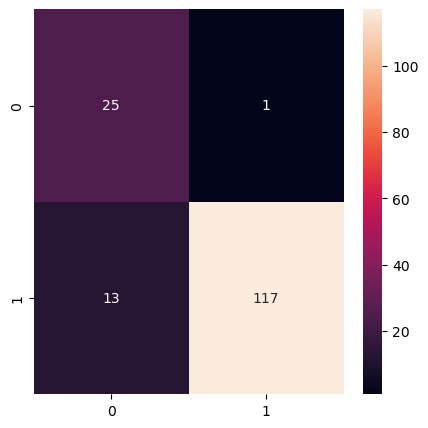

In [34]:
plt.figure(figsize = (5,5))
sns.heatmap(confusion_matrix(x_train_prediction, y_train), annot = True, fmt = "g")

<b>LogisticRegression</b>

In [35]:
logistic_model = LogisticRegression()

In [36]:
logistic_model.fit(x_train, y_train)

LogisticRegression()

In [37]:
x_train_prediction = logistic_model.predict(x_train)
training_data_accuracy = accuracy_score(y_train, x_train_prediction)

In [39]:
print("Accuracy on Training Data :", training_data_accuracy)

Accuracy on Training Data : 0.8717948717948718


In [40]:
x_test_prediction = logistic_model.predict(x_test)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)

In [41]:
print("Accuracy on Test Data :", test_data_accuracy)

Accuracy on Test Data : 0.8205128205128205


In [42]:
print("Mean Absolute Error: ", (mean_absolute_error(y_test, x_test_prediction)))

Mean Absolute Error:  0.1794871794871795


In [43]:
print("Mean Squared Error: ", (mean_squared_error(y_test, x_test_prediction)))

Mean Squared Error:  0.1794871794871795


In [44]:
print("Median Absolute Error: ", (median_absolute_error(y_test, x_test_prediction)))

Median Absolute Error:  0.0


In [45]:
print("Classification Report")
print(classification_report(y_test,x_test_prediction))
print("Confusion Matrix")
print(confusion_matrix(y_test, x_test_prediction))

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.40      0.53        10
           1       0.82      0.97      0.89        29

    accuracy                           0.82        39
   macro avg       0.81      0.68      0.71        39
weighted avg       0.82      0.82      0.80        39

Confusion Matrix
[[ 4  6]
 [ 1 28]]


<Axes: >

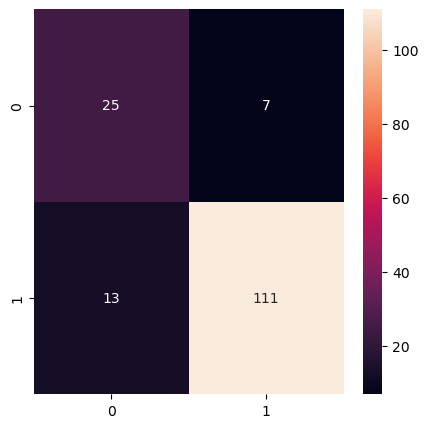

In [46]:
plt.figure(figsize = (5,5))

sns.heatmap(confusion_matrix(x_train_prediction, y_train), annot = True, fmt = "g")

<b>XGB Regressor</b>

In [48]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/150.0 MB 2.4 MB/s eta 0:01:03
   ---------------------------------------- 1.3/150.0 MB 2.3 MB/s eta 0:01:05
   ---------------------------------------- 1.6/150.0 MB 2.2 MB/s eta 0:01:08
   ---------------------------------------- 1.8/150.0 MB 2.0 MB/s eta 0:01:15
    --------------------------------------- 2.1/150.0 MB 1.9 MB/s eta 0:01:17
    --------------------------------------- 2.6/150.0 MB 1.9 MB/s eta 0:01:18
    --------------------------------------- 2.9/150.0 MB 1.9 MB/s eta 0:01:18
    --------------------------------------- 3.1/150.0 MB 1.8 MB/s eta 0:01:22
    --------------------------------------- 3.4/150.0 MB 1.8 MB/s eta 0:01:23
    --------------------------------------- 3.7/150.0 MB 1.8 MB/s eta 0:01:23
   - -------------------------------------- 3.9/150.0 MB 1.7 MB/s eta 0:01:24


In [49]:
from xgboost import XGBRegressor

regressor_model = XGBRegressor()


In [50]:
regressor_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
training_data_prediction = regressor_model.predict(x_train)

score_1 = metrics.r2_score(y_train, training_data_prediction)
print("R squared error : ", score_1)

score_2 = metrics.mean_absolute_error(y_train, training_data_prediction)
print("Mean Absolute Error : ", score_2)

R squared error :  0.999998152256012
Mean Absolute Error :  0.0003437339594781336


In [52]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the data
std_data = scaler.transform(input_data_reshaped)

prediction = svm_model.predict(std_data)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")

[0]
The Person does not have Parkinsons Disease


c:\Users\acer\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [53]:
import pickle

In [57]:
with open('Parkinsons.pkl','wb') as file:
  pickle.dump(prediction, file)

In [59]:
for column in data:
    print(column)

name
MDVP:Fo(Hz)
MDVP:Fhi(Hz)
MDVP:Flo(Hz)
MDVP:Jitter(%)
MDVP:Jitter(Abs)
MDVP:RAP
MDVP:PPQ
Jitter:DDP
MDVP:Shimmer
MDVP:Shimmer(dB)
Shimmer:APQ3
Shimmer:APQ5
MDVP:APQ
Shimmer:DDA
NHR
HNR
status
RPDE
DFA
spread1
spread2
D2
PPE


In [60]:
input_data = (197.07600,206.89600,192.05500,0.00289,0.00001,0.00166,0.00168,0.00498,0.01098,0.09700,0.00563,0.00680,0.00802,0.01689,0.00339,26.77500,0.422229,0.741367,-7.348300,0.177551,1.743867,0.085569)

# changing input data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the data
std_data = scaler.transform(input_data_reshaped)

prediction = svm_model.predict(std_data)
print(prediction)


if (prediction[0] == 0):
  print("The Person does not have Parkinsons Disease")

else:
  print("The Person has Parkinsons")

[0]
The Person does not have Parkinsons Disease


c:\Users\acer\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
